In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt


In [2]:
import pandas as pd
import os 
base_path = r"C:\Users\aishw\.cache\kagglehub\datasets\wangboluo\pamap2\versions\1"

# Adjust file names if different
train_file = os.path.join(base_path, "train.csv")
test_file  = os.path.join(base_path, "test.csv")

train_df = pd.read_csv(train_file)
test_df  = pd.read_csv(test_file)

print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)

print("\nTrain columns:\n", train_df.columns[:10], "...")
print("\nTrain sample:\n", train_df.head())

Train shape: (4489500, 38)
Test  shape: (1125500, 38)

Train columns:
 Index(['id', 'Activity', 'imu_hand_accX_16g', 'imu_hand_accY_16g',
       'imu_hand_accZ_16g', 'imu_hand_accX_6g', 'imu_hand_accY_6g',
       'imu_hand_accZ_6g', 'imu_hand_gyroX', 'imu_hand_gyroY'],
      dtype='object') ...

Train sample:
    id  Activity  imu_hand_accX_16g  imu_hand_accY_16g  imu_hand_accZ_16g  \
0   1         0           0.661126           0.421296           0.408697   
1   1         0           0.661284           0.421581           0.408104   
2   1         0           0.661837           0.421871           0.408258   
3   1         0           0.662559           0.421429           0.408268   
4   1         0           0.661320           0.422026           0.408845   

   imu_hand_accX_6g  imu_hand_accY_6g  imu_hand_accZ_6g  imu_hand_gyroX  \
0          0.471288          0.541375          0.537667        0.536450   
1          0.471682          0.541373          0.537545        0.535625   
2     

In [3]:
drop_cols = ['id','Activity']
feature_cols = [c for c in train_df.columns if c not in drop_cols and np.issubdtype(train_df[c].dtype, np.number)]

X_train = train_df[feature_cols].values
X_test  = test_df[feature_cols].values
y_test  = np.where(test_df['Activity']==0, -1, 1)

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [5]:
frac = 0.1
idx = np.random.choice(len(X_train_scaled), size=int(frac*len(X_train_scaled)), replace=False)
X_train_frac = X_train_scaled[idx]

In [6]:
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.05)
lof.fit(X_train_frac)

C:\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Python310\lib\subprocess.py", line 969, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Python310\lib\subprocess.py", line 1438, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


LocalOutlierFactor(contamination=0.05, novelty=True)

In [7]:
y_pred = lof.predict(X_test_scaled)

In [8]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=[1,-1])
anomaly_count = np.sum(y_pred==-1)
report = classification_report(y_test, y_pred, labels=[1,-1], target_names=['Normal','Anomaly'])

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Anomalies detected: {anomaly_count} / {len(y_pred)}")
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)


Accuracy: 68.05%
Anomalies detected: 81400 / 1125500
Confusion Matrix:
 [[721013  36487]
 [323087  44913]]

Classification Report:
               precision    recall  f1-score   support

      Normal       0.69      0.95      0.80    757500
     Anomaly       0.55      0.12      0.20    368000

    accuracy                           0.68   1125500
   macro avg       0.62      0.54      0.50   1125500
weighted avg       0.65      0.68      0.60   1125500



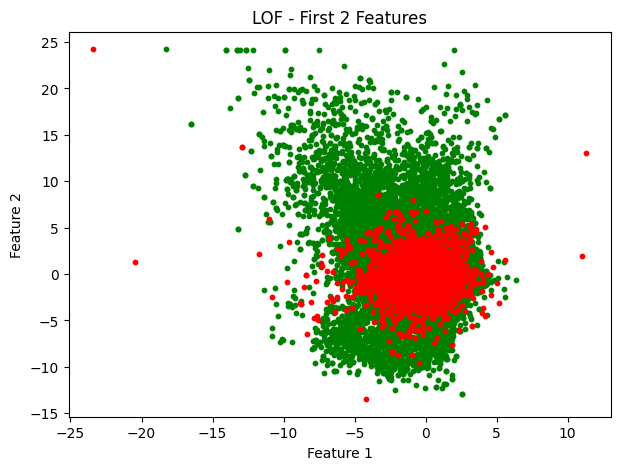

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(X_test_scaled[y_pred==1,0], X_test_scaled[y_pred==1,1], s=10, c='green')
plt.scatter(X_test_scaled[y_pred==-1,0], X_test_scaled[y_pred==-1,1], s=10, c='red')
plt.title("LOF - First 2 Features")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()